<a href="https://colab.research.google.com/github/sbooeshaghi/llmarkers/blob/main/analysis/extraction/token_aln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --quiet tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.5 MB/s eta 0:00:00


# Token based

In [2]:
import tiktoken

In [3]:
import re

def tokenize_whitespace_with_offsets(text):
    """Tokenizes text on whitespace and returns tokens with their character start and end positions."""
    tokens = []

    for word in re.finditer(r'\S+', text):  # word non-whitespace sequences
        token = word.group()
        start_idx = word.start()
        end_idx = word.end()

        tokens.append({
            "token": token,
            "start_idx": start_idx,
            "end_idx": end_idx
        })

    return tokens

def tokenize_with_offsets(text, encoding="cl100k_base"):
  """Tokenizes text and returns tokens with their character start positions."""
  enc = tiktoken.get_encoding(encoding)
  tokens = []

  etks = enc.encode(text)
  dtks, ptks = enc.decode_with_offsets(etks)

  assert len(etks) == len(ptks)

  for t,p in zip(etks, ptks):
    token = enc.decode_single_token_bytes(t).decode("utf-8")
    tobj = {
      "token": token,
      "enc_token": t,
      "start_idx": p,
      "end_idx": p + len(token)
    }
    tokens.append(tobj)
  return tokens

def tokenize_with_offsets(text, encoding="cl100k_base"):
    """Tokenizes text and returns tokens with their character start positions."""
    enc = tiktoken.get_encoding(encoding)
    tokens = []

    etks = enc.encode(text)
    dtks, ptks = enc.decode_with_offsets(etks)

    assert len(etks) == len(ptks)

    for idx, (t, p) in enumerate(zip(etks, ptks)):
        try:
            # Try with utf-8 first
            token = enc.decode_single_token_bytes(t).decode("utf-8")
        except UnicodeDecodeError:
            # Fall back to a more permissive encoding if utf-8 fails
            token = enc.decode_single_token_bytes(t).decode("latin-1")

        tobj = {
            "token": token,
            "enc_token": t,
            "start_idx": p,
            "end_idx": p + len(token),
            "token_idx": idx
        }
        tokens.append(tobj)
    return tokens

In [4]:
from collections import defaultdict
def index_source(source):
  source_tokens = tokenize_with_offsets(source)
  source_words = tokenize_whitespace_with_offsets(source)

  tokens = source_tokens

  source_index = defaultdict(list)
  for i, token in enumerate(tokens):
    source_index[token["enc_token"]].append(token)
  return source_index

def align_target(target, idx):
  pos = defaultdict(list)
  tokens = tokenize_with_offsets(target)
  aln = []
  for token_obj in tokens:
    enc_token = token_obj["enc_token"]
    if enc_token in idx.keys():
      aln.append({enc_token: idx[enc_token]})
  return aln

def deduplicate_alignments(aln):
  pos = []
  start_idx = 0

  for d in aln:
      k, v = next(iter(d.items()))
      sorted_targets = sorted(v, key=lambda x: x["start_idx"])

      # Use next with a generator expression to find the first valid match
      valid_target = next((t for t in sorted_targets if t["start_idx"] >= start_idx), None)

      if valid_target:
          start_idx = valid_target["start_idx"]
          pos.append(valid_target)

  return pos

def group_contiguous_tokens(pos):
  group = []
  g = []
  for tk in pos:
    if len(g) == 0:
      g.append(tk)
    elif g[-1]["end_idx"] == tk["start_idx"]:
      g.append(tk)
    elif g[-1]["end_idx"] < tk["start_idx"]:
      group.append({reconstruct_target_by_token("", g): g})
      g = [tk]
  group.append({reconstruct_target_by_token("", g): g})
  return group

def reconstruct_target_by_token(source, pos):
  # reconstruct the target by joining the tokens
  return "".join([i["token"] for i in pos])

def reconstruct_target_by_idx(source, pos):
  # reconstruct the target by joining the tokens
  return "".join([source[i["start_idx"]:i["end_idx"]] for i in pos])

def reconstruct_target_by_strip_token(source, pos):
  # reconstruct the target by joining the tokens
  return " ".join([i["strip_token"] for i in pos])

def align(source, target):
  idx = index_source(source)
  aln = align_target(target, idx)
  pos = deduplicate_alignments(aln)
  grp = group_contiguous_tokens(pos)
  found = reconstruct_target_by_idx(source, pos)
  return (found, grp)

import unicodedata
def norm_text(text):
    """
    Normalize text to ensure UTF-8 compatibility for NLP processing.

    This function:
    1. Normalizes Unicode to the NFC form
    2. Replaces problematic characters with ASCII equivalents
    3. Handles common special characters that cause issues

    Args:
        text (str): Input text to normalize

    Returns:
        str: Normalized text safe for UTF-8 processing
    """
    if not isinstance(text, str):
        try:
            text = str(text)
        except:
            return ""

    # Step 1: Unicode normalization to NFC form (composed form)
    # This combines characters and diacritics when possible
    text = unicodedata.normalize('NFC', text)

    # Step 2: Map specific problematic characters to ASCII equivalents
    char_map = {
        'ɛ': 'e',        # epsilon
        'ɑ': 'a',        # alpha
        'β': 'b',        # beta
        'δ': 'd',        # delta
        'γ': 'g',        # gamma
        'λ': 'l',        # lambda
        'μ': 'u',        # mu
        'π': 'pi',       # pi
        'θ': 'theta',    # theta
        'τ': 't',        # tau
        'ω': 'omega',    # omega
        '′': "'",        # prime
        '″': '"',        # double prime
        '–': '-',        # en dash
        '—': '--',       # em dash
        ''': "'",        # curly single quote
        ''': "'",        # curly single quote
        '"': '"',        # curly double quote
        '"': '"',        # curly double quote
        '…': '...',      # ellipsis
        '•': '*',        # bullet
        '·': '.',        # middle dot
        '×': 'x',        # multiplication sign
        '÷': '/',        # division sign
        '≤': '<=',       # less than or equal
        '≥': '>=',       # greater than or equal
        '≠': '!=',       # not equal
        '≈': '~',        # approximately equal
        '∞': 'inf',      # infinity
        '∂': 'd',        # partial differential
        '∫': 'integral', # integral
        '∑': 'sum',      # sum
        '∏': 'product',  # product
        '√': 'sqrt',     # square root
        '∝': 'prop to',  # proportional to
        '∠': 'angle',    # angle
        '△': 'triangle', # triangle
        '□': 'square',   # square
        '∈': 'in',       # element of
        '∉': 'not in',   # not an element of
        '⊂': 'subset',   # subset
        '⊃': 'superset', # superset
        '∪': 'union',    # union
        '∩': 'intersect',# intersection
        '⊆': 'subseteq', # subset or equal
        '⊇': 'superseteq',# superset or equal
        # Add more mappings as needed
    }

    for char, replacement in char_map.items():
        text = text.replace(char, replacement)
    # Step 3: Remove any remaining non-ASCII characters (optional)
    # Uncomment if you want to remove ALL non-ASCII characters
    # text = re.sub(r'[^\x00-\x7F]+', '', text)

    text.replace("\n", " ")

    return text

In [5]:
target = norm_text(" my name is frank")
source = norm_text("hello my name is sina, no my name is frank")

idx = index_source(source)
aln = align_target(target, idx)
pos = deduplicate_alignments(aln)
grp = group_contiguous_tokens(pos)
found = reconstruct_target_by_idx(source, pos)
print(f"target: {target}")
print(f"found : {found}")

target:  my name is frank
found :  my name is frank


In [6]:
source = norm_text("""For example, mASPC2 and hASPC2 are characterized by high expression of Aldh1a3 and ALDH1A3,
respectively, and strongly resemble previously identified early multipotent progenitor cells that
reside in the reticular interstitium of the fat pad5.""")

target = norm_text(" and strongly resemble previously identified early multipotent progenitor")

idx = index_source(source)
aln = align_target(target, idx)
pos = deduplicate_alignments(aln)
grp = group_contiguous_tokens(pos)
found = reconstruct_target_by_idx(source, pos)
print(f"target: {target}")
print(f"found : {found}")

target:  and strongly resemble previously identified early multipotent progenitor
found :  and strongly resemble previously identified early multipotent progenitor


In [7]:
target =  norm_text(" male populations")
source = norm_text("""After doublet removal and quality filtering, we considered a total of 197,721 cells (106,469 from PG and 91,252 from ING),
identifying all cell types observed in human WAT (Fig. 2c, d, Supplementary Table 2) with the addition of
distinct male and female epithelial populations (Dcdc2a+ and Erbb4+, respectively)""")

found, grp = align(source, target)
print(f"target: {target}")
print(f"found : {found}")
print(grp)

target:  male populations
found :  male populations
[{' male': [{'token': ' male', 'enc_token': 8762, 'start_idx': 237, 'end_idx': 242, 'token_idx': 63}]}, {' populations': [{'token': ' populations', 'enc_token': 22673, 'start_idx': 264, 'end_idx': 276, 'token_idx': 68}]}]


In [8]:
target = norm_text(" hASPC2")
source = norm_text("""For example, mASPC2 and hASPC2 are characterized by high expression of Aldh1a3 and ALDH1A3,
respectively, and strongly resemble previously identified early multipotent progenitor cells that reside
in the reticular interstitium of the fat pad5.""")

found, grp = align(source, target)
print(f"target: {target}")
print(f"found : {found}")
print(grp)

target:  hASPC2
found :  hASPC2
[{' hASPC2': [{'token': ' h', 'enc_token': 305, 'start_idx': 23, 'end_idx': 25, 'token_idx': 8}, {'token': 'AS', 'enc_token': 1950, 'start_idx': 25, 'end_idx': 27, 'token_idx': 9}, {'token': 'PC', 'enc_token': 4977, 'start_idx': 27, 'end_idx': 29, 'token_idx': 10}, {'token': '2', 'enc_token': 17, 'start_idx': 29, 'end_idx': 30, 'token_idx': 11}]}]


## ngram based

In [9]:
from collections import defaultdict, deque
from itertools import product

def tokenize(text):
    nt = norm_text(text)
    tks = tokenize_with_offsets(nt)
    t2w = defaultdict(list)
    for tk in tks:
        t2w[tk["enc_token"]].append(tk)
    return (tks, t2w)

def build_index(text, k=1):
  tokens, t2w = tokenize(text)
  ngram_to_id = {}  # Maps n-grams to unique IDs
  id_to_ngram = {}  # Map unique IDs to n-grams
  ngram_id_to_pos = defaultdict(list)  # Positions of each n-gram id
  ngrams = [] # actual list of ngrams (and corresponding tokens)
  counter = 0

  enc_tokens = [i["enc_token"] for i in tokens]

  for i in range(len(enc_tokens) - k + 1):
    ngram = tuple(enc_tokens[i:i + k]) # encoded tuple of tokens

    # get the ngram id or add it
    if ngram not in ngram_to_id:
      ngram_to_id[ngram] = counter
      id_to_ngram[counter] = ngram
      counter += 1
    ngram_id = ngram_to_id[ngram]

    ngram_id_to_pos[ngram_id].append(i)

    ngrams.append({"ngram_id": ngram_id, "tks": tokens[i:i + k]})

  return (ngram_to_id, id_to_ngram, ngram_id_to_pos, ngrams)

def align_target(target, ngram_to_id, ngram_id_to_pos, k=1):
  tokens, t2w = tokenize(target)

  enc_tokens = [i["enc_token"] for i in tokens]

  aln = []

  prev_id = None
  for i in range(len(enc_tokens) - k + 1):
    target_ngram = tuple(enc_tokens[i:i + k]) # build the ngram from the target

    ngram_id = ngram_to_id.get(tuple(target_ngram), None) # align the target ngram to the ngrams built from source

    if ngram_id is not None:
      if prev_id is not None and prev_id == ngram_id:
        continue  # Skip duplicate adjacent n-grams
      aln.append({target_ngram: [{"ngram_id": ngram_id, "pos": j} for j in ngram_id_to_pos[ngram_id]]})
      prev_id = ngram_id

  return aln


def group_ngrams(aln):
  # group ngram combinations (ensure positions are ordered)
  position_lists = [list(entry.values())[0] for entry in aln]

  all_combinations = list(product(*position_lists))
  grp = []
  idx = 0
  for combo in all_combinations:
    positions = [item["pos"] for item in combo]
    if positions == sorted(positions):  # Ensure positions are increasing
      grp.append(list(combo))
      idx += 1

  return grp

def group_tokens(grp, ngrams):
  # group tokens for each combination of ngrams
  tk_aln = []
  for aln_ngrams in grp:
    pos = aln_ngrams[0]["pos"]
    nid = aln_ngrams[0]["ngram_id"]

    tks = []
    tks += ngrams[pos]["tks"]

    for ng in aln_ngrams[1:]:
      pos = ng["pos"]
      nid = ng["ngram_id"]
      tks += [ngrams[pos]["tks"][-1]]
    tk_aln.append(tks)
  return tk_aln

def build_graph(ngrams, id_to_ngram):
  graph = defaultdict(set)
  for ng in ngrams:
    ngram_id = ng["ngram_id"]
    ngram = id_to_ngram[ngram_id]
    for existing_ngram_id, existing_ngram in id_to_ngram.items():
      if existing_ngram_id == ngram_id:
          continue  # Skip self

      # Check left adjacency (ngram[:-1] matches existing_ngram[1:])
      if ngram[:-1] == existing_ngram[1:]:
          graph[existing_ngram_id].add(ngram_id)

      # Check right adjacency (ngram[1:] matches existing_ngram[:-1])
      if ngram[1:] == existing_ngram[:-1]:
          graph[ngram_id].add(existing_ngram_id)
  return graph

def align_ng(source, target, k=1):
  ngram_to_id, id_to_ngram, ngram_id_to_pos, ngrams = build_index(source, k)
  aln = align_target(target, ngram_to_id, ngram_id_to_pos, k)
  if len(aln) > 0:
    grp = group_ngrams(aln)
    tks = group_tokens(grp, ngrams)
    n_aln = len(tks)

    print(f"{n_aln} alignments")
    return (tks, ngrams, id_to_ngram)
  return ([], ngrams, id_to_ngram)

In [10]:
source = "hello my name is sina no my name is frank"
target = "hello my name is frank"
src_tokens, src_t2w = tokenize(source)

k = 5
tks, ngrams, id_to_ngram = align_ng(source, target, k)

for idx, pos in enumerate(tks):
  recon = reconstruct_target_by_idx(source, pos)
  print(f"aln {idx} match ({target == recon}): '{target}' == '{recon}'")

In [11]:
g = build_graph(ngrams, id_to_ngram)

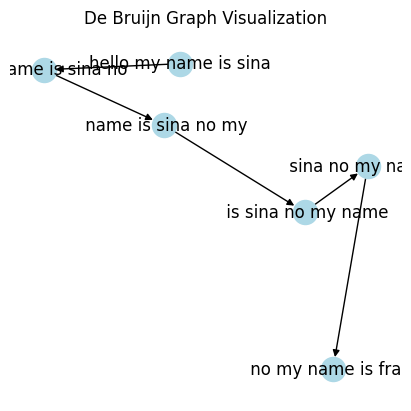

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

"""Visualize the graph using matplotlib and networkx."""
G = nx.DiGraph()

# Add nodes with labels
for node_id, ngram in id_to_ngram.items():
  w = [str(src_t2w[i][0]["token"]) for i in ngram]
  l = "".join(w)
  G.add_node(node_id, label=l)

# Add edges
for src, targets in g.items():
  for tgt in targets:
    G.add_edge(src, tgt)

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

# Reduce `k` value to make the graph more compact
pos = nx.spring_layout(G, k=1)  # Adjust k for a tighter layout

labels = {node: G.nodes[node]['label'] for node in G.nodes()}

nx.draw(
  G, pos, with_labels=True, labels=labels,
  node_color='lightblue', edge_color='black',
  arrows=True, ax=ax
)

ax.set_title("De Bruijn Graph Visualization")

plt.show()  # Correct way to display the plot


In [13]:
source = norm_text("""For example, mASPC2 and hASPC2 are characterized by high expression of Aldh1a3 and ALDH1A3,
respectively, and strongly resemble previously identified early multipotent progenitor cells that
reside in the reticular interstitium of the fat pad5.""")
target = norm_text(" and strongly resemble previously identified early multipotent progenitor")

src_tokens, src_t2w = tokenize(source)


k = 3

tks, ngrams, id_to_ngram = align_ng(source, target, k)

for idx, pos in enumerate(tks):
  recon = reconstruct_target_by_idx(source, pos)
  print(f"aln {idx} match ({target == recon}): '{target}' == '{recon}'")

1 alignments
aln 0 match (True): ' and strongly resemble previously identified early multipotent progenitor' == ' and strongly resemble previously identified early multipotent progenitor'
